<a href="https://colab.research.google.com/github/ancestor9/2026_Fall_Learning-Langchain-AI-Agent/blob/main/CH4_Using_LangGraph_to_Add_Memory_to_Your_Chatbot.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import os
from google.colab import userdata

# Groq API 키 설정
YOUR_API_KEY = userdata.get('groq')
os.environ["GROQ_API_KEY"] = YOUR_API_KEY

In [2]:
!pip install -qU langchain-groq

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.5/137.5 kB 4.2 MB/s eta 0:00:00


In [3]:
from langchain_core.prompts import ChatPromptTemplate
from langchain_groq import ChatGroq

prompt = ChatPromptTemplate.from_messages([
    ("system", "You are a helpful assistant. Answer all questions to the best of your ability."),
    ("placeholder", "{messages}"), # 단순 텍스트가 아닌 대화 기록(히스토리)을 프롬프트에 동적으로 삽입할 때 사용
])

model = ChatGroq(model="llama-3.3-70b-versatile", temperature=0)

chain = prompt | model

# 3개의 연속된 대화 내역을 리스트로 묶어 전달
response = chain.invoke({
    "messages": [
        ("human", "Translate this sentence from English to German: I love programming."),
        # ("ai", "Ich liebe das Programmieren."), # Mocking(의도적인 가짜 데이터 주입)
        ("human", "What did you just say?"),
    ],
})

print(response.content)

I translated the sentence "I love programming" into German. The translation is: "Ich liebe das Programmieren."


### 두 방식의 차이점

- "ai" 답변이 있을 때 ---> 기억하고 답변: 정말로 과거에 나눈 대화 자체를 회상(Review)하면서, 그 답변(Ich liebe das Programmieren)에 사용된 문법이나 단어(명사형/동사형 등)에 대한 깊이 있는 피드백

- "ai" 답변이 없을 때 (현재 코드) ---> 한 번에 읽고 답변: 과거 대화에 대한 피드백을 주는 게 불가능하므로, 유저의 첫 번째 요청을 그 자리에서 수행하며 "당신이 요청한 번역은 이겁니다"라고 답변을 완성

> - "ai" 턴을 빼도 말이 되는 답변이 나오는 이유는, LLM이 앞뒤 문맥을 보고 "대화가 자연스럽게 이어지도록 공백을 메우는 능력"이 매우 뛰어나기 때문


> - 사람의 착각: AI가 첫 번째 질문을 읽고 멈췄다가, 두 번째 질문을 읽고 "어라? 내가 아까 무슨 말을 했더라?" 하고 머릿속 기억을 더듬는다고 생각함.

> - 실제 컴퓨터 내부: LLM은 주석 처리된 리스트를 한 문장으로 이어 붙인 "인간: 독어로 번역해 줘. 인간: 너 방금 뭐라고 했어?"라는 전체 텍스트를 처음부터 끝까지 한 번에(동시에) 읽고 답변 (LLM이 기억하는 방식은 사람의 뇌나 컴퓨터의 하드디스크처럼 "과거의 기억을 저장해 두었다가 꺼내오는 것"은 아님)

In [4]:
# @title 랭체인의 대표적인 내장 메모리 모듈인 ChatMessageHistory

!pip install -qU langchain-community

from langchain_community.chat_message_histories import ChatMessageHistory
from langchain_core.prompts import ChatPromptTemplate
from langchain_groq import ChatGroq

# 1. 프롬프트 템플릿 정의 (placeholder 공간은 그대로 유지)
prompt = ChatPromptTemplate.from_messages([
    ("system", "You are a helpful assistant. Answer all questions to the best of your ability."),
    ("placeholder", "{messages}"),
])

# 2. 언어 모델 설정 (Groq Llama 3.1)
model = ChatGroq(model_name="llama-3.1-8b-instant", temperature=0)

# 3. 체인 구성
chain = prompt | model

# 4. 랑체인 내장 메모리 객체 생성
history = ChatMessageHistory()

# ==========================================
# 턴 1: 첫 번째 대화 (번역 요청)
# ==========================================
print("--- [Turn 1] 유저의 번역 요청 ---")
user_input_1 = "Translate this sentence from English to German: I love programming."

# 유저의 질문을 메모리에 수동(또는 자동 파이프라인)으로 추가
history.add_user_message(user_input_1)

# 메모리에 쌓인 전체 대화 기록을 꺼내서 모델에 전달
response_1 = chain.invoke({"messages": history.messages})
print(f"AI 답변: {response_1.content}\n")

# AI의 답변도 다음 대화를 위해 메모리에 자동으로 추가
history.add_ai_message(response_1.content)

# ==========================================
# 턴 2: 두 번째 대화 (이전 맥락 확인 질문)
# ==========================================
print("--- [Turn 2] 유저의 후속 질문 ---")
user_input_2 = "What did you just say?"

# 유저의 두 번째 질문을 다시 메모리에 추가
history.add_user_message(user_input_2)

# 이제 history.messages 안에는 [유저1, AI1, 유저2] 메시지가 모두 누적되어 있음
response_2 = chain.invoke({"messages": history.messages})
print(f"AI 답변:\n{response_2.content}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 55.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 35.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.7/61.7 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 4.1 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.34.2 which is incompatible.


/tmp/ipykernel_576/4120637082.py:5: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.chat_message_histories import ChatMessageHistory


--- [Turn 1] 유저의 번역 요청 ---
AI 답변: The translation of the sentence "I love programming" from English to German is:

Ich liebe Programmieren.

However, a more common and idiomatic way to express this in German would be:

Ich liebe Programmieren, or 
Ich bin ein großer Fan von Programmieren (I'm a big fan of programming), or 
Ich bin Programmierer (I'm a programmer), or 
Ich liebe es, zu programmieren (I love to program).

The first option, "Ich liebe Programmieren", is a direct translation of the original sentence.

--- [Turn 2] 유저의 후속 질문 ---
AI 답변:
I translated the sentence "I love programming" from English to German and provided a few alternative ways to express the same idea in German.


In [5]:
for turn in history.messages:
    print(turn)

content='Translate this sentence from English to German: I love programming.' additional_kwargs={} response_metadata={}
content='The translation of the sentence "I love programming" from English to German is:\n\nIch liebe Programmieren.\n\nHowever, a more common and idiomatic way to express this in German would be:\n\nIch liebe Programmieren, or \nIch bin ein großer Fan von Programmieren (I\'m a big fan of programming), or \nIch bin Programmierer (I\'m a programmer), or \nIch liebe es, zu programmieren (I love to program).\n\nThe first option, "Ich liebe Programmieren", is a direct translation of the original sentence.' additional_kwargs={} response_metadata={} tool_calls=[] invalid_tool_calls=[]
content='What did you just say?' additional_kwargs={} response_metadata={}


# **Introducing LangGraph**

In [6]:
# @title **Creating a StateGraph**

# Start by creating a StateGraph

from typing import Annotated, TypedDict
from langchain_core.messages import HumanMessage
from langchain_groq import ChatGroq
from langgraph.graph import StateGraph, START, END, add_messages

# 1. 그래프의 상태(State) 및 리듀서 정의
class State(TypedDict):
    # add_messages 리듀서가 적용된 부분입니다.
    messages: Annotated[list, add_messages]

# 2. 그래프 빌더 선언
builder = StateGraph(State)

# 3. LLM 모델을 ChatGroq(Llama 3.1)
model = ChatGroq(model_name="llama-3.1-8b-instant", temperature=0)


# 4. 챗봇 노드 함수 정의
def chatbot(state: State):
    # 상태(State) 메모장에 누적된 messages를 꺼내 LLM에 전달
    answer = model.invoke(state["messages"])

    # 리듀서(add_messages)가 작동하므로, 기존 리스트를 덮어쓰지 않고 뒤에 추가
    return {"messages": [answer]}

# 5. 노드 및 에지(흐름) 연결
builder.add_node("chatbot", chatbot)
builder.add_edge(START, "chatbot")
builder.add_edge("chatbot", END)

# 6. 그래프 컴파일 (실행 가능한 형태의 앱으로 변환)
graph = builder.compile()

# 7. 그래프 실행 및 스트리밍 출력
input_data = {"messages": [HumanMessage("hi!")]}

for chunk in graph.stream(input_data):
    print(chunk)

{'chatbot': {'messages': [AIMessage(content='How can I assist you today?', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 8, 'prompt_tokens': 37, 'total_tokens': 45, 'completion_time': 0.017367791, 'completion_tokens_details': None, 'prompt_time': 0.002709097, 'prompt_tokens_details': None, 'queue_time': 0.034077994, 'total_time': 0.020076888}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_e2c608b1d6', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019f8233-cb25-7b82-99d6-bd8a3ca1889b-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 37, 'output_tokens': 8, 'total_tokens': 45})]}}


In [7]:
[chunk for chunk in graph.stream(input_data)]

[{'chatbot': {'messages': [AIMessage(content='How can I assist you today?', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 8, 'prompt_tokens': 37, 'total_tokens': 45, 'completion_time': 0.01857967, 'completion_tokens_details': None, 'prompt_time': 0.002631018, 'prompt_tokens_details': None, 'queue_time': 0.034478299, 'total_time': 0.021210688}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_e2c608b1d6', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019f8233-cba5-7363-9c8a-78cd55824ba5-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 37, 'output_tokens': 8, 'total_tokens': 45})]}}]

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 40.3 MB/s eta 0:00:00


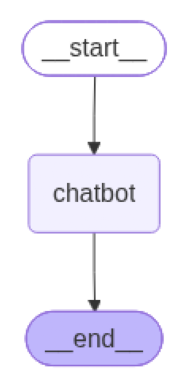

In [8]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from io import BytesIO

# Pygraphviz와 pydot이 필요합니다.
!pip install -qU pygraphviz pydot

# Graphviz가 시스템에 설치되어 있어야 합니다. Colab에서는 보통 기본 설치되어 있습니다.

# Mermaid PNG 이미지를 생성합니다.
mermaid_png_bytes = graph.get_graph().draw_mermaid_png()

# Bytes 데이터를 이미지로 로드합니다.
img = mpimg.imread(BytesIO(mermaid_png_bytes))

# 이미지를 표시합니다.
plt.imshow(img)
plt.axis('off') # 축을 비활성화합니다.
plt.show()

In [9]:
# @title **Adding Memory to StateGraph**

from langgraph.checkpoint.memory import MemorySaver

# Add persistence with MemorySaver
graph = builder.compile(checkpointer=MemorySaver())

In [10]:
from langgraph.checkpoint.memory import MemorySaver

# 5. Add persistence with MemorySaver
# graph는 실행될 때마다 대화 상대방과의 방 번호(thread_id)별로 State를 자동 저장
graph = builder.compile(checkpointer=MemorySaver())

# 6. Configure thread
# thread_id는 대화방의 '고유 방 번호(구분자)' , thread_id 덕분에 사용자별 / 대화방별로 격리된 독립된 대화 맥락(Context)을 유지
thread1 = {"configurable": {"thread_id": "1"}}

# Run with persistence
result_1 = graph.invoke({"messages": [HumanMessage("hi, my name is Jack!")]}, thread1)
print(result_1)

result_2 = graph.invoke({"messages": [HumanMessage("what is my name?")]}, thread1)
print(result_2)

# Get state
print(graph.get_state(thread1))

{'messages': [HumanMessage(content='hi, my name is Jack!', additional_kwargs={}, response_metadata={}, id='7f68cbf5-0a01-43dc-bae6-cbcb5c902075'), AIMessage(content="Hi Jack, it's nice to meet you. Is there something I can help you with or would you like to chat?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 26, 'prompt_tokens': 42, 'total_tokens': 68, 'completion_time': 0.036536223, 'completion_tokens_details': None, 'prompt_time': 0.00307348, 'prompt_tokens_details': None, 'queue_time': 0.036098204, 'total_time': 0.039609703}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_020e283281', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019f8233-e934-7ed1-9ce8-88292f424e51-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 42, 'output_tokens': 26, 'total_tokens': 68})]}
{'messages': [HumanMessage(content='hi, my name is Jack!', additional_kwargs={}, res

In [14]:
graph.get_state(thread1).metadata

{'source': 'loop', 'step': 4, 'parents': {}}

In [16]:
for message in graph.get_state(thread1).values['messages']:
    print(message.content)

hi, my name is Jack!
Hi Jack, it's nice to meet you. Is there something I can help you with or would you like to chat?
what is my name?
Your name is Jack.


# **Modifying Chat History**

In [26]:
# @title **Trimming Messages**

from langchain_core.messages import (
    SystemMessage,
    HumanMessage,
    AIMessage,
    trim_messages,
)

# Define sample messages
messages = [
    SystemMessage(content="you're a good assistant"),
    HumanMessage(content="hi! I'm bob"),
    AIMessage(content="hi!"),
    HumanMessage(content="I like vanilla ice cream"),
    AIMessage(content="nice"),
    HumanMessage(content="whats 2 + 2"),
    AIMessage(content="4"),
    HumanMessage(content="thanks"),
    AIMessage(content="no problem!"),
    HumanMessage(content="having fun?"),
    AIMessage(content="yes!"),
]

# Create trimmer
trimmer = trim_messages(
    max_tokens=65,
    strategy="last",
    token_counter=ChatGroq(model_name="llama-3.1-8b-instant", temperature=0),
    include_system=True,
    allow_partial=False,
    start_on="human",
)

# Apply trimming
trimmed = trimmer.invoke(messages)
print(trimmed)

[SystemMessage(content="you're a good assistant", additional_kwargs={}, response_metadata={}), HumanMessage(content="hi! I'm bob", additional_kwargs={}, response_metadata={}), AIMessage(content='hi!', additional_kwargs={}, response_metadata={}, tool_calls=[], invalid_tool_calls=[]), HumanMessage(content='I like vanilla ice cream', additional_kwargs={}, response_metadata={}), AIMessage(content='nice', additional_kwargs={}, response_metadata={}, tool_calls=[], invalid_tool_calls=[]), HumanMessage(content='whats 2 + 2', additional_kwargs={}, response_metadata={}), AIMessage(content='4', additional_kwargs={}, response_metadata={}, tool_calls=[], invalid_tool_calls=[]), HumanMessage(content='thanks', additional_kwargs={}, response_metadata={}), AIMessage(content='no problem!', additional_kwargs={}, response_metadata={}, tool_calls=[], invalid_tool_calls=[]), HumanMessage(content='having fun?', additional_kwargs={}, response_metadata={}), AIMessage(content='yes!', additional_kwargs={}, respo

In [27]:
for msg in trimmed:
    print(msg.content)

you're a good assistant
hi! I'm bob
hi!
I like vanilla ice cream
nice
whats 2 + 2
4
thanks
no problem!
having fun?
yes!


- max_tokens=25 으로 변경하면 줄어듬
- trim_messages() 의 다른 인자의 기능 확인하라

In [30]:
# Create trimmer
trimmer = trim_messages(
    max_tokens=25,
    strategy="last",
    token_counter=ChatGroq(model_name="llama-3.1-8b-instant", temperature=0),
    include_system=True,
    allow_partial=False,
    start_on="human",
)

# Apply trimming
trimmed = trimmer.invoke(messages)

[msg.content for msg in trimmed]

["you're a good assistant", 'thanks', 'no problem!', 'having fun?', 'yes!']

In [33]:
# @title **Filtering Messages**

from langchain_core.messages import (
 AIMessage,
 HumanMessage,
 SystemMessage,
 filter_messages,
)

messages = [
 SystemMessage("you are a good assistant", id="1"),
 HumanMessage("example input", id="2", name="example_user"),
 AIMessage("example output", id="3", name="example_assistant"),
 HumanMessage("real input", id="4", name="bob"),
 AIMessage("real output", id="5", name="alice"),
]

# 타입이 HumanMessage인 메시지들만 필터링되어 출력
filter_messages(messages, include_types="human")

[HumanMessage(content='example input', additional_kwargs={}, response_metadata={}, name='example_user', id='2'),
 HumanMessage(content='real input', additional_kwargs={}, response_metadata={}, name='bob', id='4')]

In [34]:
filter_messages(messages, exclude_names=["example_user", "example_assistant"])

[SystemMessage(content='you are a good assistant', additional_kwargs={}, response_metadata={}, id='1'),
 HumanMessage(content='real input', additional_kwargs={}, response_metadata={}, name='bob', id='4'),
 AIMessage(content='real output', additional_kwargs={}, response_metadata={}, name='alice', id='5', tool_calls=[], invalid_tool_calls=[])]

In [35]:
filter_messages(
 messages,
 include_types=[HumanMessage, AIMessage],
 exclude_ids=["3"]
)

[HumanMessage(content='example input', additional_kwargs={}, response_metadata={}, name='example_user', id='2'),
 HumanMessage(content='real input', additional_kwargs={}, response_metadata={}, name='bob', id='4'),
 AIMessage(content='real output', additional_kwargs={}, response_metadata={}, name='alice', id='5', tool_calls=[], invalid_tool_calls=[])]

In [39]:
# The filter_messages helper can also be used imperatively or declaratively, making it easy to compose with other components in a chain:

filter_ = filter_messages(exclude_names=["example_user", "example_assistant"])
chain = filter_ | model
chain.invoke(messages)

AIMessage(content='', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 1, 'prompt_tokens': 44, 'total_tokens': 45, 'completion_time': 0.004675303, 'completion_tokens_details': None, 'prompt_time': 0.003803807, 'prompt_tokens_details': None, 'queue_time': None, 'total_time': 0.00847911}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_020e283281', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019f824e-78d7-7240-88d3-744d92ce22c1-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 44, 'output_tokens': 1, 'total_tokens': 45})

In [42]:
# @title **Merging Consecutive Messages**

from langchain_core.messages import (
    AIMessage,
    HumanMessage,
    SystemMessage,
    merge_message_runs,
)

# Sample messages with consecutive messages of same type
messages = [
    SystemMessage(content="you're a good assistant."),
    SystemMessage(content="you always respond with a joke."),
    HumanMessage(
        content=[{"type": "text", "text": "i wonder why it's called langchain"}]
    ),
    HumanMessage(content="and who is harrison chasing anyways"),
    AIMessage(
        content='Well, I guess they thought "WordRope" and "SentenceString" just didn\'t have the same ring to it!'
    ),
    AIMessage(
        content="Why, he's probably chasing after the last cup of coffee in the office!"
    ),
]

# Merge consecutive messages
merged = merge_message_runs(messages)
print(merged)

[SystemMessage(content="you're a good assistant.\nyou always respond with a joke.", additional_kwargs={}, response_metadata={}), HumanMessage(content=[{'type': 'text', 'text': "i wonder why it's called langchain"}, 'and who is harrison chasing anyways'], additional_kwargs={}, response_metadata={}), AIMessage(content='Well, I guess they thought "WordRope" and "SentenceString" just didn\'t have the same ring to it!\nWhy, he\'s probably chasing after the last cup of coffee in the office!', additional_kwargs={}, response_metadata={}, tool_calls=[], invalid_tool_calls=[])]


In [45]:
# HumanMessage 2개와 AIMessage 2개는 실제로 합쳐졌고, SystemMessage는 안 합쳐짐

for msg in merged:
    print(msg.content)

you're a good assistant.
you always respond with a joke.
[{'type': 'text', 'text': "i wonder why it's called langchain"}, 'and who is harrison chasing anyways']
Well, I guess they thought "WordRope" and "SentenceString" just didn't have the same ring to it!
Why, he's probably chasing after the last cup of coffee in the office!


In [46]:
merger = merge_message_runs()
chain = merger | model